In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("synthetic_dataset.csv")
df.head()

,x1,x2,y
0,-1.5,-1.0,0
1,-1.2,-0.8,0
2,-0.9,-1.2,0
3,-0.6,-0.9,0
4,-0.3,-1.1,0


Separating features and labels

In [27]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (111, 2)
y shape: (111,)


Converting labels to -1 & +1

In [3]:
y = np.where(y == 0, -1, 1)

splitting data into training and testing

In [28]:
np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.8 * len(X))
train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

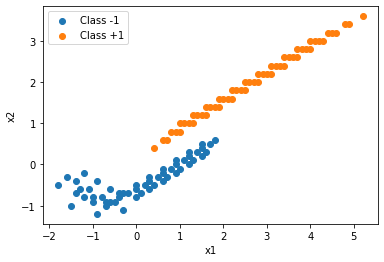

In [4]:
plt.scatter(X[y == -1][:,0], X[y == -1][:,1], label='Class -1')
plt.scatter(X[y == 1][:,0], X[y == 1][:,1], label='Class +1')
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

Creating SVM class

In [34]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1
            if condition:
                self.w -= self.lr * (2 * self.lambda_param * self.w)
            else:
                self.w -= self.lr * (2 * self.lambda_param * self.w -y[idx] * x_i)
                self.b -= self.lr * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)

Training the SVM

In [6]:
svm = SVM()
svm.fit(X, y)

Making predictions

In [7]:
predictions = svm.predict(X)

In [8]:
accuracy = np.mean(predictions == y)
accuracy

0.8018018018018018

Euclidean distance

KNN from scratch

In [54]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

class KNN:
    def __init__(self, k=3):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def _predict_one(self, X):
        distances = []
        for i in range(len(self.X_train)):
            dist = euclidean_distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))

        distances.sort(key=lambda x: x[0])
        k_nearest_labels = [label for (_, label) in distances[:self.k]]
        return np.sign(sum(k_nearest_labels))    
    def predict(self, x):
        predictions = []
        for x in X:
            predictions.append(self.predict_one(x))
        return np.array(predictions)

Testing KNN

In [62]:
split_index = int(0.8 * len(X))
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [63]:
knn = KNN(k=3)
knn.fit(X_train, y_train)

In [70]:
knn_predictions = []

for x in X_test:
    pred = knn_predict(X_train, y_train, x, k=3)
    knn_predictions.append(pred)

knn_predictions = np.array(knn_predictions)

In [ ]:
accuracy = np.mean(knn_predictions == y_test)
print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.5652173913043478


In [80]:
accuracy = np.mean(knn_predictions == y_test)
print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.0


C:\Users\Humera Siddiqua\AppData\Local\Temp\ipykernel_24592\3950806015.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  accuracy = np.mean(knn_predictions == y_test)


In [81]:
knn = KNN(k=7)
knn.fit(X_train, y_train)

svm = SVM()
svm.fit(X_train, y_train)

In [82]:
knn_pred = knn.predict(X_test)
svm_pred = svm.predict(X_test)

AttributeError: 'KNN' object has no attribute 'predict_one'

In [83]:
print("KNN Accuracy :", accuracy_score(y_test, knn_pred))
print("SVM Accuracy :", accuracy_score(y_test, svm_pred))

print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))

NameError: name 'accuracy_score' is not defined